In [9]:
import sys
import os
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = os.path.abspath("..") 
sys.path.append(PROJECT_ROOT)

In [ ]:
from utils.feature_engineering import get_between_features, get_elapsed_feature
from dataset.otto_trace import TraceOttoDataSet
from torch.utils.data import random_split

In [11]:
dataset_processed = TraceOttoDataSet(
    file_name='../train.jsonl',
    input_seq_len=64,
    min_timestamps_per_sample=16,
    max_samples=500000
)

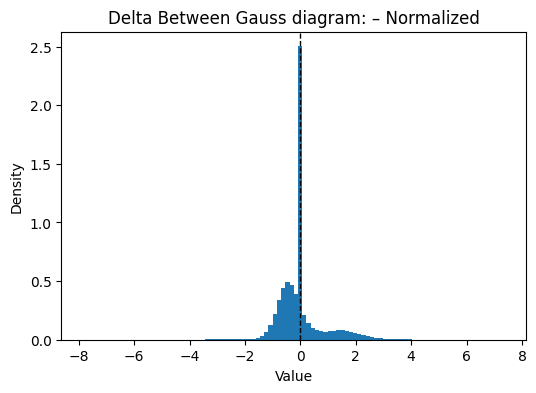

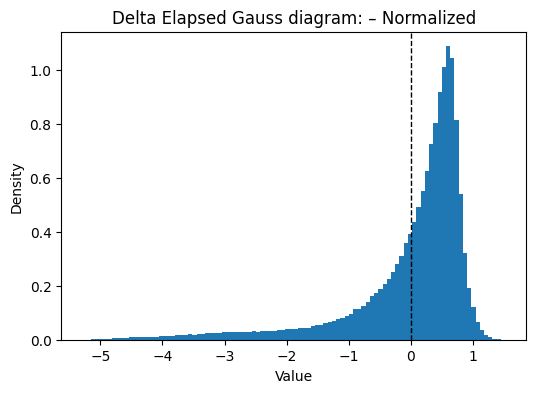

Delta Between: 251758
mean:  -4.4455079e-10
std:  0.8144937
max|x|:  7.8727536

Delta Elapsed:
 mean: -1.0370966e-08
 std : 0.9842502
max|x|: 5.289007


In [ ]:
train_portion = 0.80
train_data, test_data = random_split(dataset=dataset_processed, lengths=[train_portion, 1 - train_portion])


train_loader = DataLoader(
    dataset=train_data,
    batch_size=32,
    shuffle=True
)



delta_elapsed_normalized = []
delta_between_normalized = []
for i, batch_trainer in enumerate(train_loader):
    evidence = batch_trainer["inputs"]
    timestamps = evidence["timestamps"]

    delta_elapsed_normalized.append(get_elapsed_feature(timestamps))
    delta_between_normalized.append(get_between_features(timestamps))
    

delta_between_graph = torch.cat([d.flatten() for d in delta_between_normalized]).cpu().numpy()
delta_elapsed_graph = torch.cat([d.flatten() for d in delta_elapsed_normalized]).cpu().numpy()


"""
Histograms of the normalization of the delta_between_normalized and delta_elapsed_normalizeds
"""
plt.figure(figsize=(6,4))
plt.hist(delta_between_graph, bins=100, density=True)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Delta Between Gauss diagram: – Normalized")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(delta_elapsed_graph, bins=100, density=True)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Delta Elapsed Gauss diagram: – Normalized")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()


print(f"Delta Between: {len(dataset_processed)}")
print("mean: ", delta_between_graph.mean())
print("std: ", delta_between_graph.std())
print("max|x|: ", np.max(np.abs(delta_between_graph)))

print("\nDelta Elapsed:")
print(" mean:", delta_elapsed_graph.mean())
print(" std :", delta_elapsed_graph.std())
print("max|x|:", np.max(np.abs(delta_elapsed_graph)))